# Chapter 2 Companion — Quantum Mechanics

Runnable companions to the worked examples in
[`docs/02_quantum_mechanics`](../docs/02_quantum_mechanics):

- [`02_qubits_and_the_bloch_sphere.md`](../docs/02_quantum_mechanics/02_qubits_and_the_bloch_sphere.md)
- [`05_density_matrices_and_open_systems.md`](../docs/02_quantum_mechanics/05_density_matrices_and_open_systems.md)
- [`09_perturbation_theory.md`](../docs/02_quantum_mechanics/09_perturbation_theory.md) (Rabi problem)
- [`10_distance_measures_and_lindblad.md`](../docs/02_quantum_mechanics/10_distance_measures_and_lindblad.md)

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=6, suppress=True)

I2 = np.eye(2, dtype=complex)
X = np.array([[0, 1], [1, 0]], dtype=complex)
Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)
H = np.array([[1, 1], [1, -1]], dtype=complex) / np.sqrt(2)
S = np.array([[1, 0], [0, 1j]], dtype=complex)

def bloch_vector(state_or_rho):
    a = np.asarray(state_or_rho)
    rho = np.outer(a, a.conj()) if a.ndim == 1 else a
    return np.array([np.trace(rho @ P).real for P in (X, Y, Z)])

## Example 1 — Bloch dynamics of `(√3|0⟩ + i|1⟩)/2` under S and H

*Docs: `02_qubits_and_the_bloch_sphere.md`, "Worked Example".* The state has
`(θ, φ) = (π/3, π/2)` and Bloch vector `r = (0, √3/2, 1/2)`. The S gate (a `π/2` z-rotation)
carries it to `r' = (−√3/2, 0, 1/2)`; the H gate (swap x↔z, negate y) carries the original
to `r'' = (1/2, −√3/2, 0)`.

In [2]:
psi = np.array([np.sqrt(3), 1j]) / 2

r = bloch_vector(psi)
print("r        =", r, "  docs: (0, √3/2, 1/2) =", (0, np.sqrt(3)/2, 0.5))
assert np.allclose(r, [0, np.sqrt(3)/2, 0.5])

r_S = bloch_vector(S @ psi)
print("after S  =", r_S, "  docs: (-√3/2, 0, 1/2)")
assert np.allclose(r_S, [-np.sqrt(3)/2, 0, 0.5])

r_H = bloch_vector(H @ psi)
print("after H  =", r_H, "  docs: (1/2, -√3/2, 0)")
assert np.allclose(r_H, [0.5, -np.sqrt(3)/2, 0])

# S preserves r_z and rotates (r_x, r_y) by +90 degrees, as a z-rotation must
print("|r| preserved by both gates:",
      np.isclose(np.linalg.norm(r_S), 1), np.isclose(np.linalg.norm(r_H), 1))

r        = [0.       0.866025 0.5     ]   docs: (0, √3/2, 1/2) = (0, np.float64(0.8660254037844386), 0.5)
after S  = [-0.866025  0.        0.5     ]   docs: (-√3/2, 0, 1/2)
after H  = [ 0.5      -0.866025  0.      ]   docs: (1/2, -√3/2, 0)
|r| preserved by both gates: True True


## Example 2 — Rabi oscillations: formula vs. RK4 integration

*Docs: `09_perturbation_theory.md`, "Worked Example: Driving a Transmon".* A 5 GHz transmon
driven at `Ω/2π = 20 MHz`:

- **Resonant** (`Δ=0`): `t_π = 25.0 ns`, `P₁(t_π) = 1`.
- **Detuned** (`Δ/2π = 20 MHz`): `Ω_R/2π = 28.28 MHz`, `P₁^max = 1/2`,
  and `P₁(10 ns) = 0.301224` — the docs cross-check Rabi's formula
  `P₁(t) = (Ω²/Ω_R²) sin²(Ω_R t/2)` against direct RK4 integration of
  `iċ = H_RWA c` with `H_RWA = (Δ/2)Z + (Ω/2)X`, and so do we.

resonant: Omega_R/2pi = 20.00 MHz, P1_max = 1.000
detuned: Omega_R/2pi = 28.28 MHz, P1_max = 0.500
pi-pulse duration t_pi = 25.0 ns (docs: 25.0 ns)
P1(10 ns) detuned:  RK4 = 0.301224, formula = 0.301224 (docs: 0.301224)


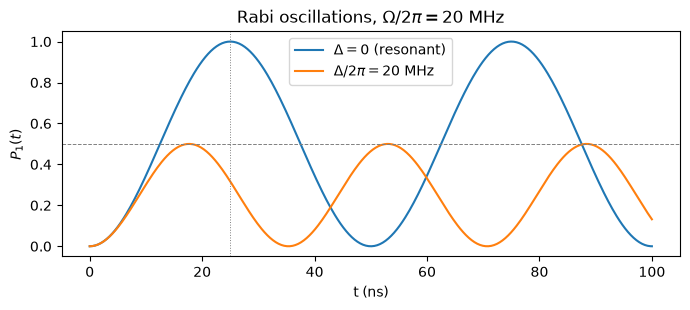

In [3]:
Omega = 2 * np.pi * 20e6            # rad/s
for name, Delta in [("resonant", 0.0), ("detuned", 2 * np.pi * 20e6)]:
    Omega_R = np.sqrt(Omega**2 + Delta**2)
    print(f"{name}: Omega_R/2pi = {Omega_R/2/np.pi/1e6:.2f} MHz, "
          f"P1_max = {Omega**2/Omega_R**2:.3f}")

t_pi = np.pi / Omega
print(f"pi-pulse duration t_pi = {t_pi*1e9:.1f} ns (docs: 25.0 ns)")
assert np.isclose(t_pi, 25e-9)

def rabi_formula(t, Delta):
    Omega_R = np.sqrt(Omega**2 + Delta**2)
    return (Omega**2 / Omega_R**2) * np.sin(Omega_R * t / 2)**2

def integrate_rk4(t_end, Delta, dt=1e-11):
    Hrwa = 0.5 * (Delta * Z + Omega * X)
    rhs = lambda c: -1j * (Hrwa @ c)
    c = np.array([1, 0], dtype=complex)
    for _ in range(int(round(t_end / dt))):
        k1 = rhs(c); k2 = rhs(c + dt/2*k1); k3 = rhs(c + dt/2*k2); k4 = rhs(c + dt*k3)
        c = c + dt/6 * (k1 + 2*k2 + 2*k3 + k4)
    return abs(c[1])**2

Delta = 2 * np.pi * 20e6
p_num = integrate_rk4(10e-9, Delta)
p_form = rabi_formula(10e-9, Delta)
print(f"P1(10 ns) detuned:  RK4 = {p_num:.6f}, formula = {p_form:.6f} (docs: 0.301224)")
assert np.isclose(p_num, 0.301224, atol=2e-6) and np.isclose(p_form, p_num, atol=1e-5)

t = np.linspace(0, 100e-9, 400)
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(t * 1e9, rabi_formula(t, 0.0), label=r"$\Delta = 0$ (resonant)")
ax.plot(t * 1e9, rabi_formula(t, Delta), label=r"$\Delta/2\pi = 20$ MHz")
ax.axhline(0.5, color="gray", lw=0.7, ls="--")
ax.axvline(25, color="gray", lw=0.7, ls=":")
ax.set_xlabel("t (ns)"); ax.set_ylabel(r"$P_1(t)$")
ax.set_title("Rabi oscillations, $\\Omega/2\\pi = 20$ MHz")
ax.legend(); fig.tight_layout(); plt.show()

## Example 3 — Phase damping of `|+⟩`: Bloch shrinkage and entropy

*Docs: `05_density_matrices_and_open_systems.md`, "Worked Example".* Under the phase-flip
channel `ε(ρ) = (1−p)ρ + pZρZ`, the state `|+⟩⟨+|` becomes
`ρ(p) = ½[[1, 1−2p],[1−2p, 1]]` with Bloch vector `(1−2p, 0, 0)`; it is maximally mixed at
`p = 1/2`, and its von Neumann entropy is the binary entropy `H(p)` (rising to 1 bit at
`p = ½`, then back to 0 at `p = 1` where the channel is the unitary `Z`).

rho(p=1/4) =
 [[0.5  0.25]
 [0.25 0.5 ]]
Bloch vector: [0.5 0.  0. ]   docs: (1-2p, 0, 0) = (0.5, 0, 0)


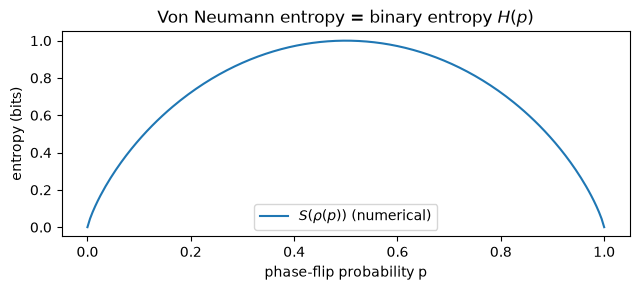

S(0), S(1/2), S(1) = 3.2034265038149176e-16 1.0 3.2034265038149176e-16  docs: 0, 1, 0


In [4]:
plus = np.array([1, 1], dtype=complex) / np.sqrt(2)
rho0 = np.outer(plus, plus.conj())

def phase_flip(rho, p):
    return (1 - p) * rho + p * (Z @ rho @ Z)

rho_q = phase_flip(rho0, 0.25)
print("rho(p=1/4) =\n", rho_q.real)        # docs: [[.5,.25],[.25,.5]]
print("Bloch vector:", bloch_vector(rho_q), "  docs: (1-2p, 0, 0) = (0.5, 0, 0)")
assert np.allclose(bloch_vector(rho_q), [0.5, 0, 0])
assert np.allclose(phase_flip(rho0, 0.5), np.eye(2)/2)   # maximally mixed at p = 1/2

def von_neumann_entropy(rho):
    lam = np.linalg.eigvalsh(rho)
    lam = lam[lam > 1e-12]
    return float(-np.sum(lam * np.log2(lam)))

ps = np.linspace(0, 1, 201)
Ss = [von_neumann_entropy(phase_flip(rho0, p)) for p in ps]
fig, ax = plt.subplots(figsize=(6.5, 3))
ax.plot(ps, Ss, label=r"$S(\rho(p))$ (numerical)")
ax.set_xlabel("phase-flip probability p"); ax.set_ylabel("entropy (bits)")
ax.set_title("Von Neumann entropy = binary entropy $H(p)$")
ax.legend(); fig.tight_layout(); plt.show()
print("S(0), S(1/2), S(1) =", Ss[0], Ss[100], Ss[200], " docs: 0, 1, 0")
assert np.isclose(Ss[100], 1.0) and Ss[0] < 1e-9 and Ss[200] < 1e-9

## Example 4 — Trace distance, fidelity, and Fuchs–van de Graaff

*Docs: `10_distance_measures_and_lindblad.md`, "Worked Example".* With `ρ = |+⟩⟨+|` and
`σ` = the phase-flipped state at `p = 1/4`:

- `D(ρ,σ) = ¼` (both from eigenvalues of `ρ−σ` and from `½|r−s|` in the Bloch picture),
- `F(ρ,σ) = ¾` (full definition, `⟨+|σ|+⟩`, qubit determinant formula, Bloch form),
- FvdG check: `1 − √F ≈ 0.1340 ≤ D = 0.25 ≤ √(1−F) = 0.5`.

In [5]:
from scipy.linalg import sqrtm

rho = rho0                      # |+><+|
sigma = phase_flip(rho0, 0.25)

# Trace distance: half the sum of |eigenvalues| of rho - sigma
diff_evals = np.linalg.eigvalsh(rho - sigma)
D_matrix = 0.5 * np.sum(np.abs(diff_evals))
D_bloch = 0.5 * np.linalg.norm(bloch_vector(rho) - bloch_vector(sigma))
print("eigenvalues of rho - sigma:", diff_evals, " docs: ±1/4")
print(f"trace distance: matrix route = {D_matrix:.4f}, Bloch route = {D_bloch:.4f} (docs: 0.25)")
assert np.isclose(D_matrix, 0.25) and np.isclose(D_bloch, 0.25)

# Fidelity (squared convention), four ways
sq = sqrtm(rho)
F_full = np.trace(sqrtm(sq @ sigma @ sq)).real**2
F_pure = (plus.conj() @ sigma @ plus).real                    # rho is pure
F_qubit = np.trace(rho @ sigma).real + 2*np.sqrt(max(np.linalg.det(rho).real, 0)
                                                 * max(np.linalg.det(sigma).real, 0))
F_bloch = 0.5 * (1 + bloch_vector(rho) @ bloch_vector(sigma))
print(f"fidelity: full={F_full:.4f}, <+|s|+>={F_pure:.4f}, "
      f"qubit-formula={F_qubit:.4f}, Bloch={F_bloch:.4f}  (docs: 0.75)")
for F in (F_full, F_pure, F_qubit, F_bloch):
    assert np.isclose(F, 0.75, atol=1e-8)

lo, hi = 1 - np.sqrt(F_full), np.sqrt(1 - F_full)
print(f"Fuchs-van de Graaff: {lo:.6f} <= {D_matrix:.2f} <= {hi:.2f}  (docs: 0.133975 ≤ 0.25 ≤ 0.5)")
assert lo <= D_matrix <= hi
print(f"optimal single-shot discrimination: p = (1+D)/2 = {(1+D_matrix)/2:.3f} (docs: 62.5%)")

eigenvalues of rho - sigma: [-0.25  0.25]  docs: ±1/4
trace distance: matrix route = 0.2500, Bloch route = 0.2500 (docs: 0.25)
fidelity: full=0.7500, <+|s|+>=0.7500, qubit-formula=0.7500, Bloch=0.7500  (docs: 0.75)
Fuchs-van de Graaff: 0.133975 <= 0.25 <= 0.50  (docs: 0.133975 ≤ 0.25 ≤ 0.5)
optimal single-shot discrimination: p = (1+D)/2 = 0.625 (docs: 62.5%)


## Example 5 — Lindblad dynamics: T₁/T₂ Bloch decay and the `T₂ ≤ 2T₁` budget

*Docs: `10_distance_measures_and_lindblad.md`.* Integrating the qubit Lindblad equation with
amplitude-damping (`L = √γ σ₋`) plus pure-dephasing (`L = √(γ_φ/2) σ_z`) dissipators must
reproduce the Bloch solutions `r_x(t) = r_x(0)e^{−t/T₂}`, `r_z(t) = 1 + (r_z(0)−1)e^{−t/T₁}`
with `1/T₂ = 1/(2T₁) + 1/T_φ`. Exercise 5's numbers: `T₁ = 80 μs`, `T₂ = 60 μs`
⟹ `T_φ = 96 μs`; doubling `T₁` gives `T₂ = 960/13 ≈ 73.8 μs`.

T_phi = 96.0 us (docs: 96 us);  T1-limit 2*T1 = 160 us
if T1 doubled: T2 = 73.8 us (docs: 960/13 ≈ 73.8 us)


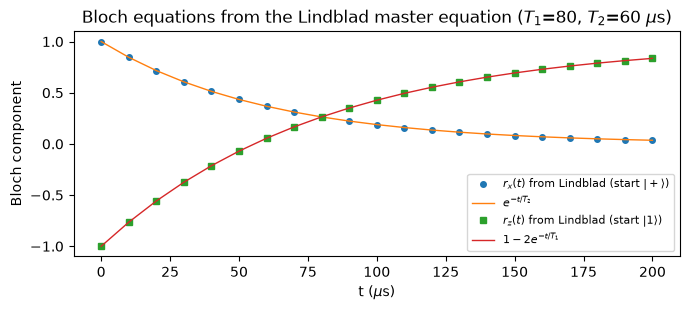

Lindblad integration matches the closed-form Bloch decays. ✓


In [6]:
T1, T2 = 80.0, 60.0                        # microseconds
inv_Tphi = 1/T2 - 1/(2*T1)
Tphi = 1/inv_Tphi
print(f"T_phi = {Tphi:.1f} us (docs: 96 us);  T1-limit 2*T1 = {2*T1:.0f} us")
assert np.isclose(Tphi, 96.0)
T2_doubled = 1 / (1/(2*2*T1) + 1/Tphi)
print(f"if T1 doubled: T2 = {T2_doubled:.1f} us (docs: 960/13 ≈ 73.8 us)")
assert np.isclose(T2_doubled, 960/13)

# Integrate the Lindblad master equation and compare to the exponential solutions
gamma, gamma_phi = 1/T1, inv_Tphi
sm = np.array([[0, 1], [0, 0]], dtype=complex)          # sigma_- = |0><1|
Ls = [np.sqrt(gamma) * sm, np.sqrt(gamma_phi/2) * Z]

def lindblad_rhs(rho):
    out = np.zeros_like(rho)
    for L in Ls:
        out += L @ rho @ L.conj().T - 0.5 * (L.conj().T @ L @ rho + rho @ L.conj().T @ L)
    return out

# start at |+> rotated slightly toward |1>: r(0) = (1, 0, -0.5)/norm — any state works;
# use r(0) = (1,0,0) i.e. |+> for the transverse channel and |1> for the longitudinal one.
def evolve(rho, t_end, dt=0.02):
    for _ in range(int(round(t_end / dt))):
        k1 = lindblad_rhs(rho); k2 = lindblad_rhs(rho + dt/2*k1)
        k3 = lindblad_rhs(rho + dt/2*k2); k4 = lindblad_rhs(rho + dt*k3)
        rho = rho + dt/6*(k1 + 2*k2 + 2*k3 + k4)
    return rho

ts = np.linspace(0, 200, 21)
rx, rz = [], []
rho_plus = 0.5*np.array([[1, 1], [1, 1]], dtype=complex)   # |+>: r=(1,0,0)
rho_one  = np.array([[0, 0], [0, 1]], dtype=complex)       # |1>: r=(0,0,-1)
for t in ts:
    rx.append(bloch_vector(evolve(rho_plus, t))[0])
    rz.append(bloch_vector(evolve(rho_one, t))[2])
rx, rz = np.array(rx), np.array(rz)

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(ts, rx, "o", ms=4, label=r"$r_x(t)$ from Lindblad (start $|+\rangle$)")
ax.plot(ts, np.exp(-ts/T2), "-", lw=1, label=r"$e^{-t/T_2}$")
ax.plot(ts, rz, "s", ms=4, label=r"$r_z(t)$ from Lindblad (start $|1\rangle$)")
ax.plot(ts, 1 - 2*np.exp(-ts/T1), "-", lw=1, label=r"$1-2e^{-t/T_1}$")
ax.set_xlabel(r"t ($\mu$s)"); ax.set_ylabel("Bloch component")
ax.set_title(r"Bloch equations from the Lindblad master equation ($T_1$=80, $T_2$=60 $\mu$s)")
ax.legend(fontsize=8); fig.tight_layout(); plt.show()
assert np.allclose(rx, np.exp(-ts/T2), atol=2e-3)
assert np.allclose(rz, 1 - 2*np.exp(-ts/T1), atol=2e-3)
print("Lindblad integration matches the closed-form Bloch decays. ✓")